In [1]:
# --- VIT TRAINING — SNIPPET 1: Imports ---

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import h5py
import numpy as np
import timm
import random
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [2]:
# ===== ViT SNIPPET 1 — mount + HDF5 loader + sampler + dataloaders =====

from google.colab import drive
drive.mount('/content/drive')

import h5py, numpy as np, torch, random
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"
IMG_SIZE = 224

class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False, augment_prob=0.5):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]    # (N,224,224,3), float32, standardized
        self.y = self.h5["y"]
        self.train = train
        self.augment_prob = augment_prob

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]            # HWC float32 standardized
        label = int(self.y[idx])

        img_t = torch.from_numpy(img).permute(2,0,1).float()

        # lightweight augmentations (safe on standardized images)
        if self.train:
            if random.random() < self.augment_prob:
                img_t = torch.flip(img_t, dims=[2])   # horizontal flip
            if random.random() < (self.augment_prob * 0.3):
                angle = random.uniform(-10, 10)
                try:
                    import torchvision.transforms.functional as TF
                    img_t = TF.rotate(img_t, angle=angle, resample=False, expand=False)
                except Exception:
                    pass

        return img_t, torch.tensor(label, dtype=torch.long)

# instantiate datasets
train_ds = H5Dataset(TRAIN_H5, train=True, augment_prob=0.5)
test_ds  = H5Dataset(TEST_H5, train=False, augment_prob=0.0)

print("Dataset sizes — train:", len(train_ds), " test:", len(test_ds))

# weighted sampler for imbalance
train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)
print("Class counts (train):", class_counts)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# dataloaders (keep workers <= 2)
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Dataloaders ready — train batches:", len(train_loader), " val batches:", len(val_loader))


Mounted at /content/drive
Device: cuda
Dataset sizes — train: 7177  test: 1803
Class counts (train): [5946 1231]
Dataloaders ready — train batches: 225  val batches: 57


In [3]:
# ===== ViT SNIPPET 2 — model, loss, optimizer, scaler =====

import timm
import torch.nn as nn

# Create ViT-B16 model
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,      # ImageNet pretrained backbone
    num_classes=2
)

model = model.to(device)
print("ViT model created:", type(model))

# ----- Class weights (same as EfficientNet) -----
count_au = class_counts[0]
count_tp = class_counts[1]
total = count_au + count_tp

w_au = total / (2 * count_au)   # ~0.6035
w_tp = total / (2 * count_tp)   # ~2.9151

weights = torch.tensor([w_au, w_tp], dtype=torch.float32).to(device)
print("Class Weights:", weights)

criterion = nn.CrossEntropyLoss(weight=weights)

# ----- Optimizer -----
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# ----- Scheduler -----
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10   # 10 epochs total
)

# ----- AMP -----
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()

print("Optimizer, loss, scheduler, AMP ready.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT model created: <class 'timm.models.vision_transformer.VisionTransformer'>
Class Weights: tensor([0.6035, 2.9151], device='cuda:0')
Optimizer, loss, scheduler, AMP ready.


/tmp/ipython-input-2430939704.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [4]:
# =========== ViT SNIPPET 3 — Training Loop ===========

import time
from torch.cuda.amp import autocast

EPOCHS = 10
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path = "/content/drive/MyDrive/morph_project/models/vit_retrained.pth"


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


# ------------------- TRAINING DRIVER -------------------

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {time.time() - t0:.1f} sec")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"🔥 Saved BEST ViT model (val acc: {val_acc*100:.2f}%)")


print("\nViT Training complete!")


/tmp/ipython-input-1835534610.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/10
Train Loss: 0.5448 | Train Acc: 51.16%
Val   Loss: 1.2478 | Val   Acc: 17.42%
Time: 172.9 sec
🔥 Saved BEST ViT model (val acc: 17.42%)

Epoch 2/10
Train Loss: 0.4526 | Train Acc: 51.19%
Val   Loss: 1.1935 | Val   Acc: 17.91%
Time: 94.6 sec
🔥 Saved BEST ViT model (val acc: 17.91%)

Epoch 3/10
Train Loss: 0.4442 | Train Acc: 51.44%
Val   Loss: 0.8913 | Val   Acc: 44.09%
Time: 100.2 sec
🔥 Saved BEST ViT model (val acc: 44.09%)

Epoch 4/10
Train Loss: 0.4141 | Train Acc: 56.50%
Val   Loss: 1.2781 | Val   Acc: 36.00%
Time: 98.5 sec

Epoch 5/10
Train Loss: 0.3549 | Train Acc: 65.19%
Val   Loss: 1.2746 | Val   Acc: 37.16%
Time: 93.0 sec

Epoch 6/10
Train Loss: 0.2820 | Train Acc: 75.23%
Val   Loss: 0.7776 | Val   Acc: 67.33%
Time: 93.3 sec
🔥 Saved BEST ViT model (val acc: 67.33%)

Epoch 7/10
Train Loss: 0.2247 | Train Acc: 82.10%
Val   Loss: 0.6874 | Val   Acc: 74.60%
Time: 99.7 sec
🔥 Saved BEST ViT model (val acc: 74.60%)

Epoch 8/10
Train Loss: 0.1662 | Train Acc: 88.53%
Val   L

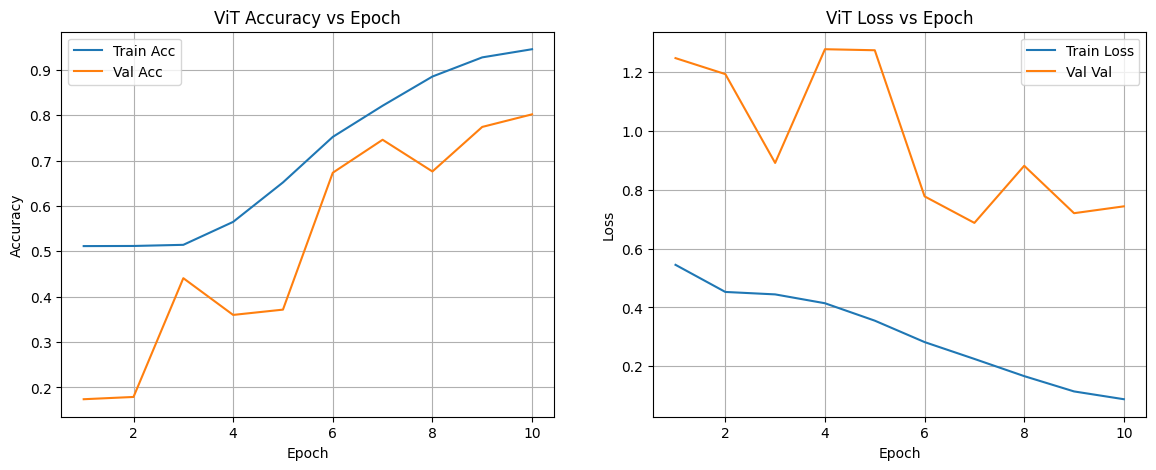

In [5]:
# ===== ViT SNIPPET 4 — Accuracy & Loss Plots =====

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Accuracy vs Epoch")
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()


Confusion Matrix:
 [[1277  212]
 [ 145  169]]


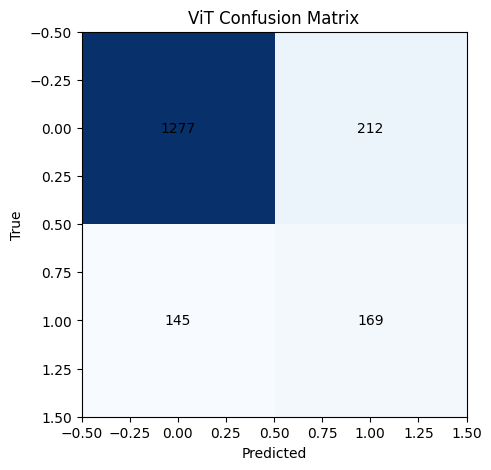


Classification Report:
              precision    recall  f1-score   support

      AU (0)       0.90      0.86      0.88      1489
      TP (1)       0.44      0.54      0.49       314

    accuracy                           0.80      1803
   macro avg       0.67      0.70      0.68      1803
weighted avg       0.82      0.80      0.81      1803



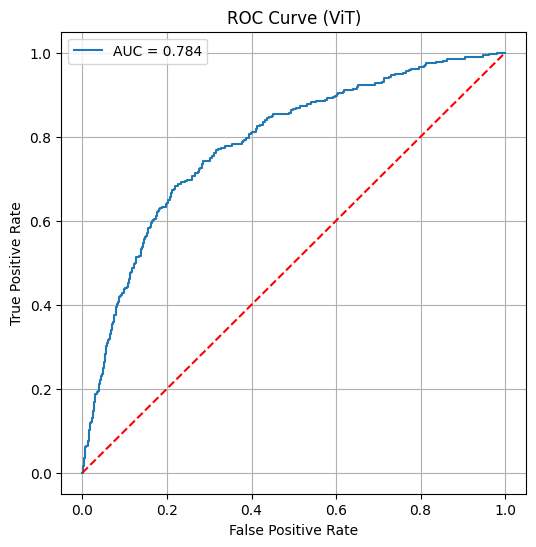


Final ViT AUC: 0.784


In [6]:
# ===== ViT SNIPPET 5 — FINAL EVALUATION =====

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for imgs, labels in val_loader:   # val_loader is your TEST set here
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())  # prob of TP class


# ------------------ CONFUSION MATRIX ------------------

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.show()


# ------------------ CLASSIFICATION REPORT ------------------

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["AU (0)", "TP (1)"]))


# ------------------ ROC + AUC ------------------

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ViT)")
plt.legend()
plt.grid()
plt.show()

print(f"\nFinal ViT AUC: {roc_auc:.3f}")


In [8]:
# ================================
# VI T  --  FINAL INFERENCE CELL
# ================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -------------------------
# Universal Preprocessing
# -------------------------

MEAN = -2.6647588e-06
STD  = 0.9996273

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Denoise
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    # Histogram Equalization (Y channel)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # Sharpen
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    img = cv2.filter2D(img, -1, kernel)

    img = img.astype(np.float32) / 255.0
    img = (img - MEAN) / (STD + 1e-7)

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)
    return img.to(device)

# -------------------------
# Load ViT Model
# -------------------------

model_path = "/content/drive/MyDrive/morph_project/models/vit_retrained.pth"

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✅ ViT Model Loaded Successfully!")

# -------------------------
# Prediction Function
# -------------------------

def predict_image(path):
    img = preprocess_image(path)

    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0]

    pred = probs.argmax().item()
    confidence = float(probs[pred] * 100)

    label = "Authentic (AU, 0)" if pred == 0 else "Tampered (TP, 1)"

    print("\n===========================")
    print(f"IMAGE: {path}")
    print(f"PREDICTION: {label}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print("===========================\n")

# -------------------------
# Upload & Predict
# -------------------------

uploaded = files.upload()
for name in uploaded.keys():
    predict_image(name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
✅ ViT Model Loaded Successfully!


Saving cpymv1.png to cpymv1.png

IMAGE: cpymv1.png
PREDICTION: Authentic (AU, 0)
CONFIDENCE: 97.65%

